In [1]:
%run utilities_general.ipynb 
%run utilities_DIRKs_and_PIRKs.ipynb
load_standard_packages()
change_wordir()
import itertools as it
from tqdm import tqdm
from matplotlib.lines import Line2D

C:\Users\andre\AppData\Local\Temp\ipykernel_17820\1467589274.py:1: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.1)
  from scipy import interpolate
Could not find cannot import name 'dopri5' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'rodas' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'odassl' from 'assimulo.lib' (c:\Users\andre\miniconda3\envs\python312\Lib\site-packages\assimulo\lib\__init__.py)
Could not find ODEPACK functions.
Could not find RADAR5
Could not find GLIMDA.


1.58.0


In [32]:
analysis = "PIRKs"

colors, colours = colourblind_palette("own")

#model = "saadat21"
#model = "ODE_v0"
#model = "ODE_v1"
#model = "new_PSI"
#model = "new_PSs"
#model = "new_b6f"
model = "with_dpsi"
#model = "latest_dev"

m = load_model(model)


succesfully loaded with_dpsi :D


In [33]:
# I like to have light as a derived variable --> enables easy plotting of shaded areas
m.add_algebraic_module(module_name = "Light",
    function = lambda X, PFD: PFD, # X is not used
    compounds = ["PQ"], derived_compounds = ["L"], parameters = ['pfd'])

In [34]:
y0 = get_stst_y0(m, pfd=800)

# simlulation

In [62]:
s = Simulator(m)

ss_pfd = 1500
pre_PIRK_time = 0.01518
drk_pfd = 0 # 10 is already enough to accumulate ATP "in the dark" # drk = dark
pls_pfd = 2500 #1180           # pls = pulse
pls_t = 0.002024 # seconds     # pulse time

#read: until <time> there is a pfd of <pfd>. then, ...
protocol = [(pre_PIRK_time, ss_pfd), (pls_t, pls_pfd), (0.01518, drk_pfd),
            (pls_t, pls_pfd), (0.02024, drk_pfd),
            (pls_t, pls_pfd), (0.04048, drk_pfd), (pls_t, pls_pfd),
            (0.08196, drk_pfd), (pls_t, pls_pfd), (0.16192, drk_pfd), (pls_t, pls_pfd), (0.32384, drk_pfd),(pls_t, pls_pfd), (0.32384, drk_pfd)
            ]

c, v = apply_protocol(s, protocol, use_tqdm = True, shift_time = False, output_in_ms = True)

100%|██████████| 15/15 [00:09<00:00,  1.66it/s]


In [63]:
# c = checkpoint("c", f"{model}/{analysis}", "c", overwrite=True) # to recover original code quickly once changed
# v = checkpoint("v", f"{model}/{analysis}", "v", overwrite=True)

# c = checkpoint("c", f"{model}/{analysis}", "c", overwrite=True) 
# v = checkpoint("v", f"{model}/{analysis}", "v", overwrite=True)

# main readouts

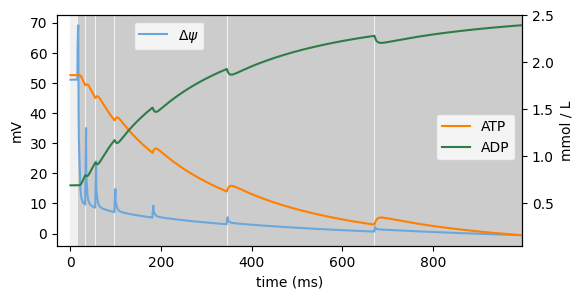

In [81]:
fig,ax1=plt.subplots(figsize=(6,3))
ax2 = ax1.twinx()

ax1.plot(c["dpsi"]*1e6, label=r"$\Delta \psi$", color=colors[0])
#ax1.plot(c["pH"]*100-590, label="pH", color=colors[3])
# ax1.plot(c["pH"], label=r"$\Delta pH$", color=colors[0])
ax2.plot(c["ATP"], label="ATP", color=colors[1])
ax2.plot(c["ADP"], label="ADP", color=colors[2])

shade_light(c, (ax1))

ax1.set(xlim=(-30,c.index[-1]),
    #xlim=(477.5,479),
    #xlim=(-1e-3, 1e-2),
    #ylim=(0.0,10),
    xlabel=("time (ms)"),
    ylabel=("mV")
    )
ax2.set(ylabel=("mmol / L"))

#legends
ax1.legend(loc="upper left", bbox_to_anchor=(0.15, 1))
ax2.legend(loc = "upper right", bbox_to_anchor=(1, 0.6))

#ax1.set_yscale("log")
fig.show()

In [13]:
save_fig(fig, model, analysis, "dpsi_ATP_ADP_plot")

existing figure backed up to figures/with_dpsi/PIRKs/Z_backup_dpsi_ATP_ADP_plot.png
saved figure to figures/with_dpsi/PIRKs/dpsi_ATP_ADP_plot.png


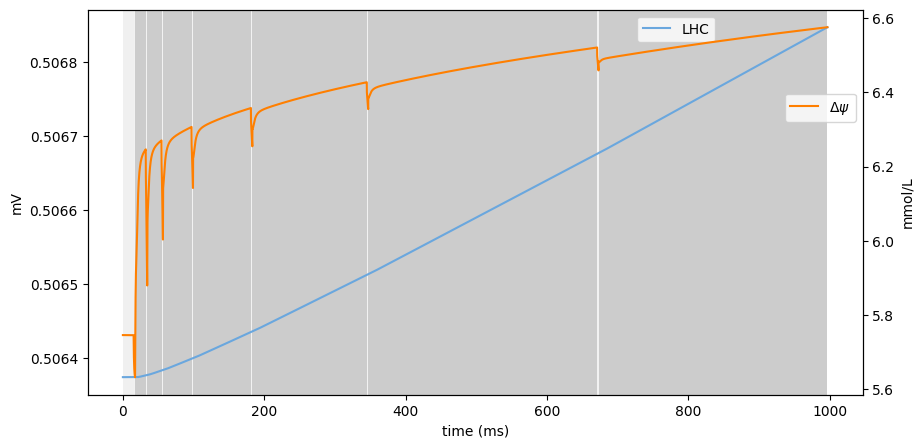

In [73]:
fig,ax1=plt.subplots(figsize=(10,5))
ax2 = ax1.twinx()

ax1.plot(c["LHC"], label="LHC", color=colors[0])
ax2.plot(c["pH"], label=r"$\Delta \psi$", color=colors[1])
#ax1.plot(v["vB12"], label="vPSII", color=colors[2])
# ax1.plot(v["vB6f"], label="vB6f", color=colors[3])

shade_light(c, (ax1))

ax1.set(#xlim=(-30,c.index[-1]),
    #xlim=(0,150),
    #xlim=(-1e-3, 1e-2),
    #ylim=(0.005,600),
    xlabel=("time (ms)"),
    ylabel=("mV")
    )
ax2.set(ylabel=("mmol/L"))

#legends
ax1.legend(loc="upper left", bbox_to_anchor=(0.7, 1))
ax2.legend(loc = "upper right", bbox_to_anchor=(1, 0.8))

# ax1.set_yscale("log")
fig.show()

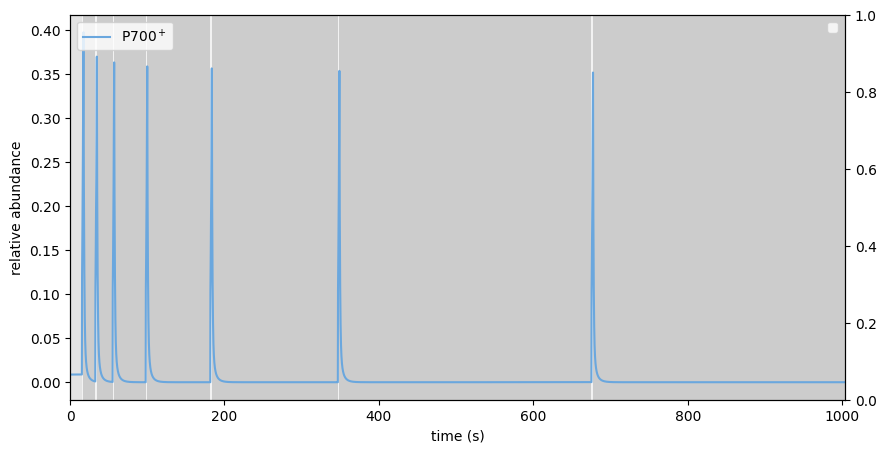

In [68]:
#two readouts

fig,ax1=plt.subplots(figsize=(10,5))
ax2 = ax1.twinx()

ax1.plot(c["rel_P700+"], label="P700$^+$", color=colors[0])
# ax2.plot(c["PC_redoxstate"], label="$PC^-$", color=colors[1])
# ax2.plot(c["Fd_redoxstate"], label="$Fd^-$", color=colors[2])

shade_light(c, (ax1))

ax1.set(xlim=(-0.05,c.index[-1]),
    #xlim=(-1e-3, 1e-2),
    #ylim=(0.0,0.005),
    xlabel=("time (s)"),
    ylabel=("relative abundance"))

#legends
ax1.legend(loc="upper left", bbox_to_anchor=(0, 1))
ax2.legend(loc = "upper right", bbox_to_anchor=(1, 1))

#ax1.set_yscale("log")
fig.show()

# Fluorescence signal  

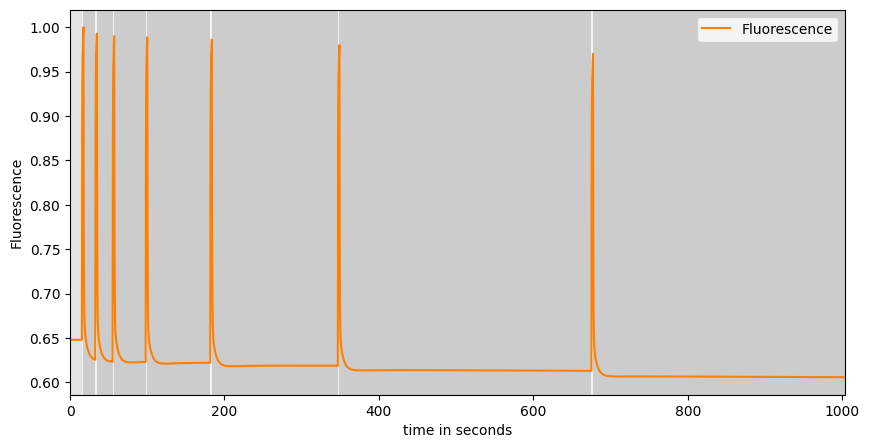

In [69]:
# Fluorescence

fig,ax=plt.subplots(figsize=(10,5))
ax.plot(c["Fluo"]/max(c["Fluo"]), label="Fluorescence", color=colours["orange"])
ax.set(ylabel=("Fluorescence"))
ax.set(xlim=(-0.05,c.index[-1]),
       #ylim=(0.16,0.5),
       xlabel=("time in seconds"),
       ylabel=("Fluorescence"))

shade_light(c, (ax))

ax.legend()
plt.show()

In [7]:
save_fig(fig, model, analysis, "Fluorescence")

# PSI states

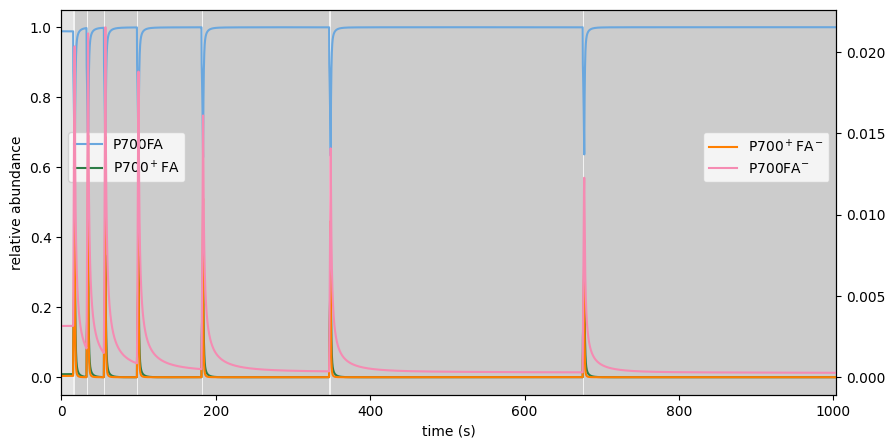

In [70]:
#PSI

fig,ax1=plt.subplots(figsize=(10,5))
ax2 = ax1.twinx()

ax1.plot(c["rel_P700FA"], label="P700FA", color=colors[0])
ax2.plot(c["rel_P700+FA-"], label="P700$^+$FA$^-$", color=colors[1])
ax1.plot(c["rel_P700+FA"], label="P700$^+$FA", color=colors[2])

if not model in ["cyclic_2021", "cyclic_2021_ODE"]:
       ax2.plot(c["rel_P700FA-"], label="P700FA$^{-}$", color=colors[3])

shade_light(c, (ax1))

ax1.set(xlim=(-0.05,c.index[-1]),
       #xlim=(-1e-3, 1e-2),
       #ylim=(0.16,0.5),
       xlabel=("time (s)"),
       ylabel=("relative abundance"))

#legends
ax1.legend(loc="upper left", bbox_to_anchor=(0, 0.7))
ax2.legend(loc = "upper right", bbox_to_anchor=(1, 0.7))

#ax1.set_yscale("log")
fig.show()

In [8]:
save_fig(fig, model, analysis, "PSI_states")

# PSII states

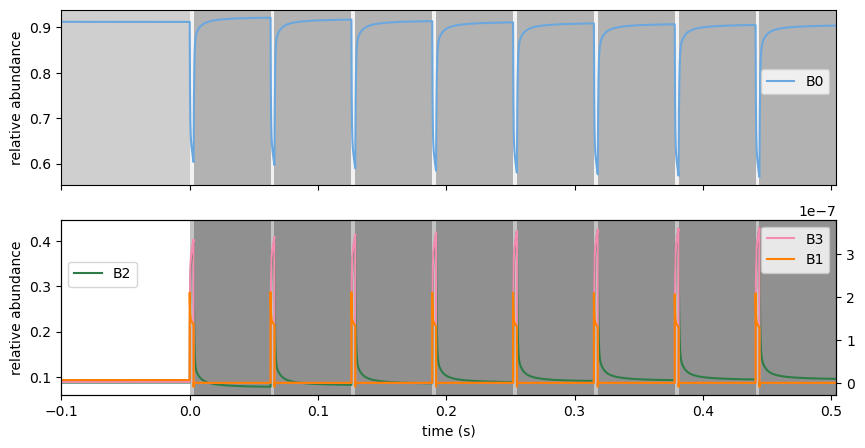

In [12]:
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(10,5), sharex=True)
ax21 = ax2.twinx()

ax1.plot(c["rel_B0"], label="B0", color=colors[0])
ax2.plot(c["rel_B2"], label="B2", color =colors[2])
ax21.plot(c["rel_B3"], label="B3", color=colors[3])
ax21.plot(c["rel_B1"], label="B1", color=colors[1])

#dark periods
shade_light(c, (ax1, ax2), max_alpha=0.3)

ax1.set(xlim=(159.99,160.25),
    #xlim=(159.9995, 160.004),
    #ylim=(0.16,0.5),
    ylabel=("relative abundance"))

#ax2.set_yscale("log")
ax2.set(xlim=(-0.1,c.index[-1]),
    #xlim=(159.9995, 160.004),
    #ylim=(-.00000005, 0.000001),
    xlabel=("time (s)"),
    ylabel=("relative abundance"))

#legends
ax1.legend(loc="upper right", bbox_to_anchor=(1, 0.7))
ax2.legend(loc = "upper left", bbox_to_anchor=(0, .8))
ax21.legend(loc = "upper right", bbox_to_anchor=(1, 1))

fig.show()

In [10]:
save_fig(fig, model, analysis, "PSII_states")

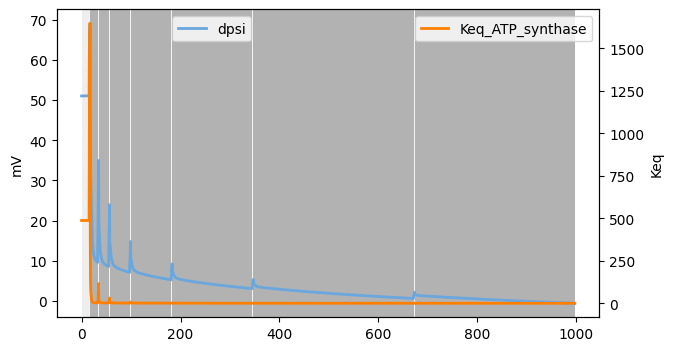

In [86]:
fig,ax1=plt.subplots(1,1,figsize=(7,4), sharex=True)
ax2 = ax1.twinx()

ax1.plot(c["dpsi"]*1e6, label="dpsi", color=colors[0], linewidth = 2)
# ax1.plot(c["ATP"] / 3.2e-2 / c["Keq_ATPsynthase"], label="ldsfkjsldkfj", color =colors[2])
ax2.plot(c["Keq_ATPsynthase"], label="Keq_ATP_synthase", color=colors[1], linewidth = 2)
# ax2.plot(c["ATP"], label="ATP", color=colors[1])

#dark periods
shade_light(c,ax1, max_alpha=0.3)

ax1.set(#xlim=(159.99,160.25),
    #xlim=(159.9995, 160.004),
    #ylim=(0.16,0.5),
    #yscale="log",
    ylabel=("mV"))

#ax2.set_yscale("log")
ax2.set(#xlim=(-0.1,c.index[-1]),
    #xlim=(159.9995, 160.004),
    #ylim=(-.00000005, 0.000001),
    #yscale="log",
    xlabel=("time (s)"),
    ylabel=("Keq"))

#legends
ax1.legend(loc="upper left", bbox_to_anchor=(0.2, 1))
ax2.legend(loc = "upper right", bbox_to_anchor=(1, 1))

fig.show()

# ATP-synthase

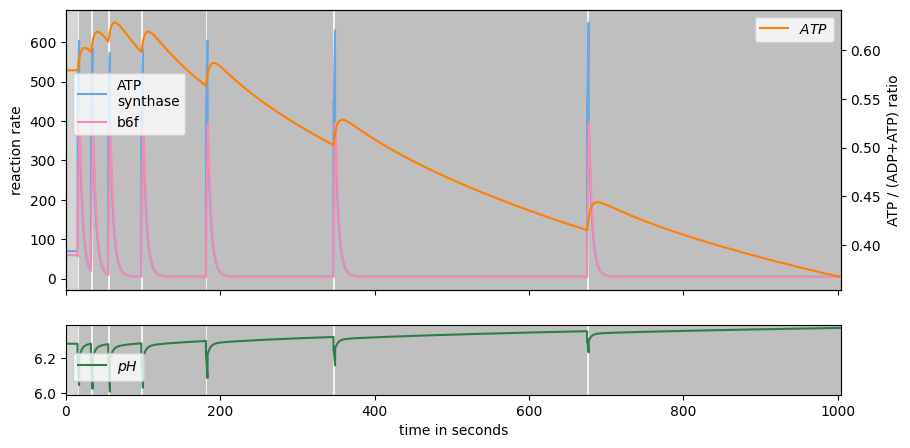

In [105]:
#ATP synthase

fig,(ax1, ax2) = plt.subplots(2, 1, figsize=(10,5), sharex = True, gridspec_kw={'height_ratios': [0.8, 0.2]})
ax11 = ax1.twinx()

ax1.set_ylabel("reaction rate")
ax1.plot(v["vATPsynthase"], color=colors[0], label="ATP\nsynthase")
ax1.plot(v["vB6f"], color=colors[3], label="b6f")

ax11.set(ylabel=("ATP / (ADP+ATP) ratio"))
ax11.plot(c["ATP_norm"], color=colors[1], label="$ATP$")

ax2.plot(c["pH"], color=colors[2], label="$pH$")

ax2.set(xlim=(-0.1, c.index[-1]),
       #xlim=(0.002,0.004),
       #ylim=(0.16,0.5),
       xlabel=("time in seconds"))

# dark periods
info = shade_light(c, (ax1, ax2), max_alpha=0.25)
       
ax1.legend(loc="upper left", bbox_to_anchor=(0, 0.8))
ax11.legend(loc="upper right", bbox_to_anchor=(1, 1))
ax2.legend(loc="upper left", bbox_to_anchor=(0, 0.7))

fig.show()

In [12]:
save_fig(fig, model, analysis, "ATP_synthase")

# electron carriers

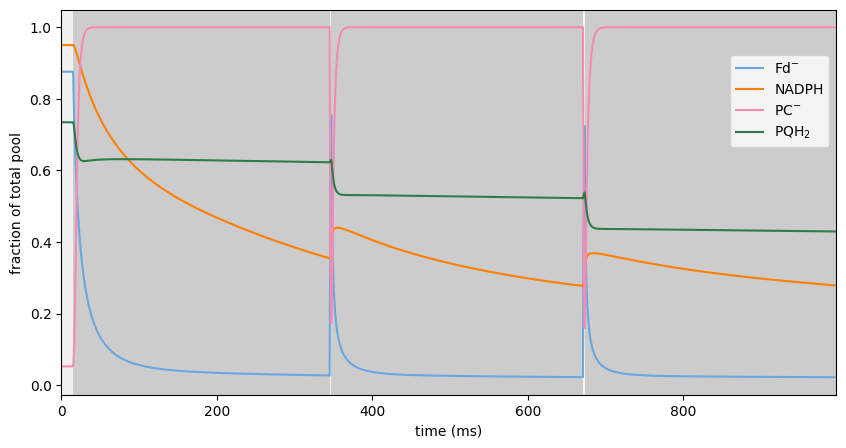

In [58]:
#electron carriers

fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))
#ax2 = ax1.twinx()

ax1.plot(c["Fd_redoxstate"], label = "Fd$^{-}$", color=colors[0])
ax1.plot(c["NADP_redoxstate"], label = "NADPH", color=colors[1])
ax1.plot(c["PC_redoxstate"], label = "PC$^{-}$", color=colors[3])
ax1.plot(c["PQ_redoxstate"], label = "PQH$_{2}$", color=colors[2])
#ax1.plot(c["LHC"], label = "LHC", color=colors[4])

#ax2 = c.loc[:,["H2O2"]].plot(ax = ax2, color = colors[4], label = "H$_2$O$_2$")

shade_light(c, (ax1))

ax1.set(xlim=(-0.1,c.index[-1]),
        #ylim=(0.16,0.5),
        xlabel=("time (ms)"),
        ylabel=("fraction of total pool"))

# ax2.set_ylabel("metabolite concentration")
# ax2.tick_params(axis='y')

ax1.set_ylabel("fraction of total pool")
ax1.tick_params(axis='y')

ax1.legend(loc='upper right', bbox_to_anchor=(1, 0.9))
# ax2.legend(loc='upper right', bbox_to_anchor=(1, 0.55))

In [14]:
save_fig(fig, model, analysis, "electron_carriers")

# PSI and electron carriers

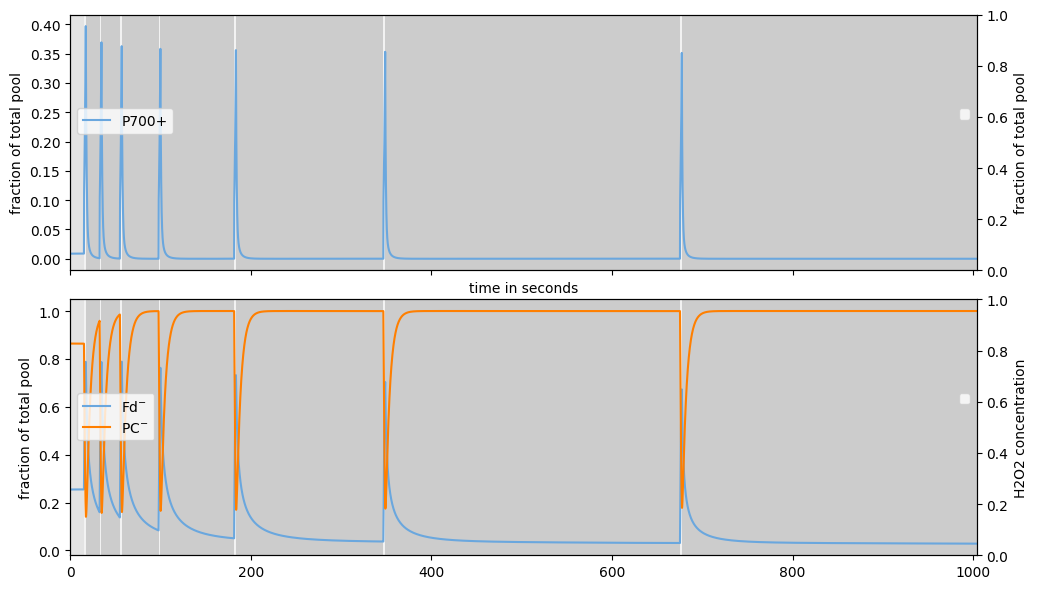

In [74]:
# PSI + electron carriers

fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax11 = ax1.twinx()
ax21 = ax2.twinx()
fig.tight_layout()

ax1.plot(c["rel_P700+"], label="P700+", color=colors[0])

# ax1.plot(c["rel_P700FA"], label="P700FA", color=colors[0])
# ax11.plot(c["rel_P700+FA-"], label="P700$^+$FA$^-$", color=colors[1])
# ax1.plot(c["rel_P700+FA"], label="P700$^+$FA", color =colors[2])
# if model != "cyclic_2021":
#         ax11.plot(c["rel_P700FA-"], label = "P700FA$^{-}$", color=colors[3])

ax2.plot(c["Fd_redoxstate"], label = "Fd$^{-}$", color=colors[0])
ax2.plot(c["PC_redoxstate"], label = "PC$^{-}$", color=colors[1])

# ax21.plot(c["H2O2"], label = "H2O$_{2}$", linestyle ="-", color=colors[2])

shade_light(c, (ax1, ax2))

ax1.set(xlim=(-0.1,c.index[-1]),
        #ylim=(0.16,0.5),
        xlabel=("time in seconds"),
        ylabel=("fraction of total pool"))
ax11.set_ylabel("fraction of total pool")
ax2.set_ylabel("fraction of total pool")
ax21.set_ylabel("H2O2 concentration")

ax1.legend(loc='upper left', bbox_to_anchor=(0, 0.66))
ax11.legend(loc='upper right', bbox_to_anchor=(1, 0.66))
ax2.legend(loc='upper left', bbox_to_anchor=(0, 0.66))
ax21.legend(loc='upper right', bbox_to_anchor=(1, 0.66))

fig.show()

In [16]:
save_fig(fig, model, analysis, "PSI_and_electron_carriers")

# Calvin cycle intermediates

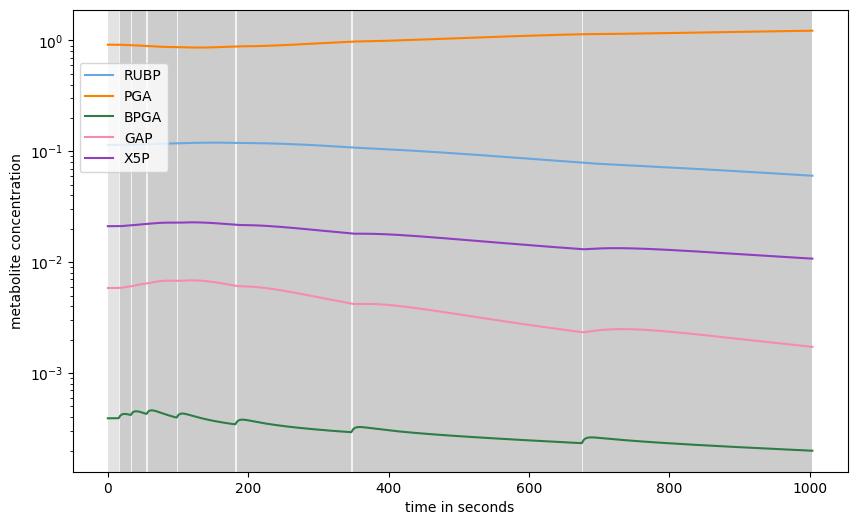

In [77]:
# Calvin cycle intermediates

fig, ax1 = plt.subplots(1, 1, figsize=(10, 6))

ax1.set_ylabel("metabolite concentration")
ax1.plot(c["RUBP"], label = "RUBP", color=colors[0])
ax1.plot(c["PGA"], label = "PGA", color=colors[1])
ax1.plot(c["BPGA"], label = "BPGA", color=colors[2])
ax1.plot(c["GAP"], label = "GAP", color=colors[3])
ax1.plot(c["X5P"], label = "X5P", color=colors[4])

shade_light(c, (ax1))

ax1.set(yscale="log")
ax1.set(#xlim=(159.95,160.25),
        #ylim=(0,0.1),
        xlabel=("time in seconds"))

ax1.legend(loc='upper left', bbox_to_anchor=(0, 0.9))

fig.show()


In [18]:
save_fig(fig, model, analysis, "CBBC_intermediates")